<>:90: SyntaxWarning: invalid escape sequence '\['
<>:91: SyntaxWarning: invalid escape sequence '\['
<>:90: SyntaxWarning: invalid escape sequence '\['
<>:91: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_4826/2632640352.py:90: SyntaxWarning: invalid escape sequence '\['
  X_train.columns = X_train.columns.str.replace('[ \[\]<>]', '_', regex=True)
/tmp/ipykernel_4826/2632640352.py:91: SyntaxWarning: invalid escape sequence '\['
  X_test.columns = X_test.columns.str.replace('[ \[\]<>]', '_', regex=True)


Veri yükleniyor ve ön işleme yapılıyor...


/tmp/ipykernel_4826/2632640352.py:18: DtypeWarning: Columns (13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('kickstarter.csv', encoding='latin1', on_bad_lines='skip')


Modeller eğitiliyor, bu işlem yaklaşık 1-2 dakika sürebilir...



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:50:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


----------------------------------------
MODEL DOĞRULUK (ACCURACY) SONUÇLARI
----------------------------------------
Logistic Regression: %64.93
Random Forest      : %63.56
XGBoost            : %66.68



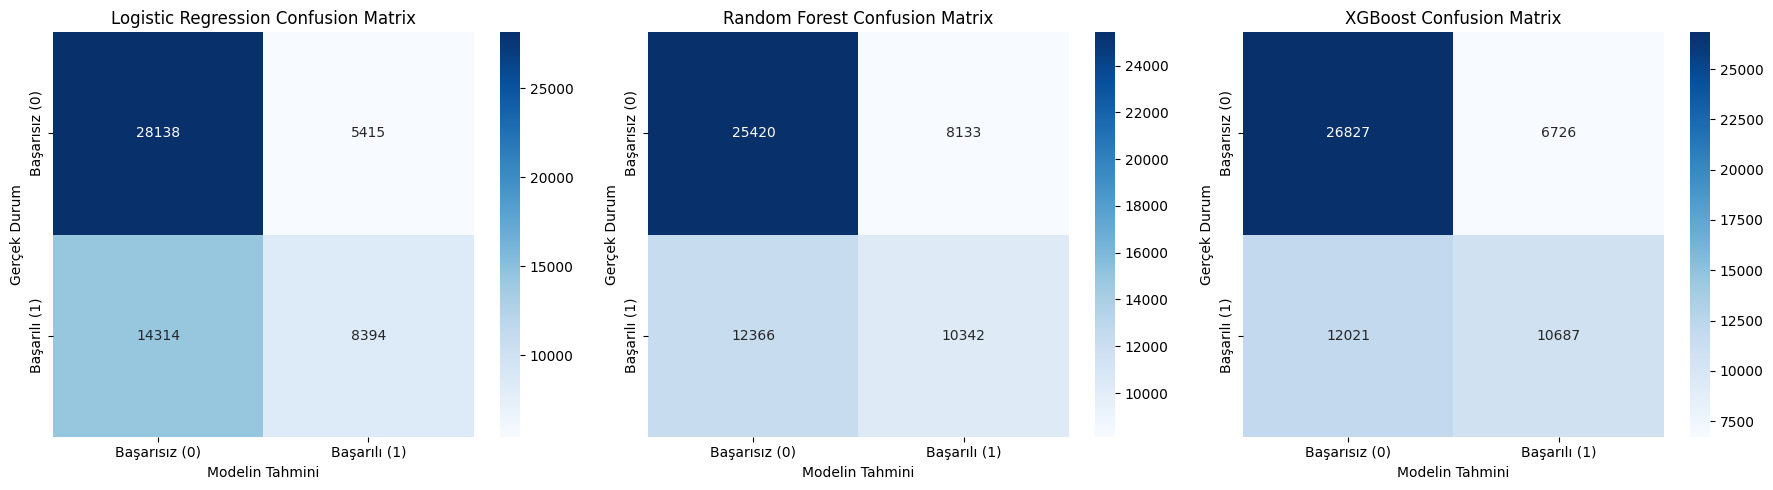

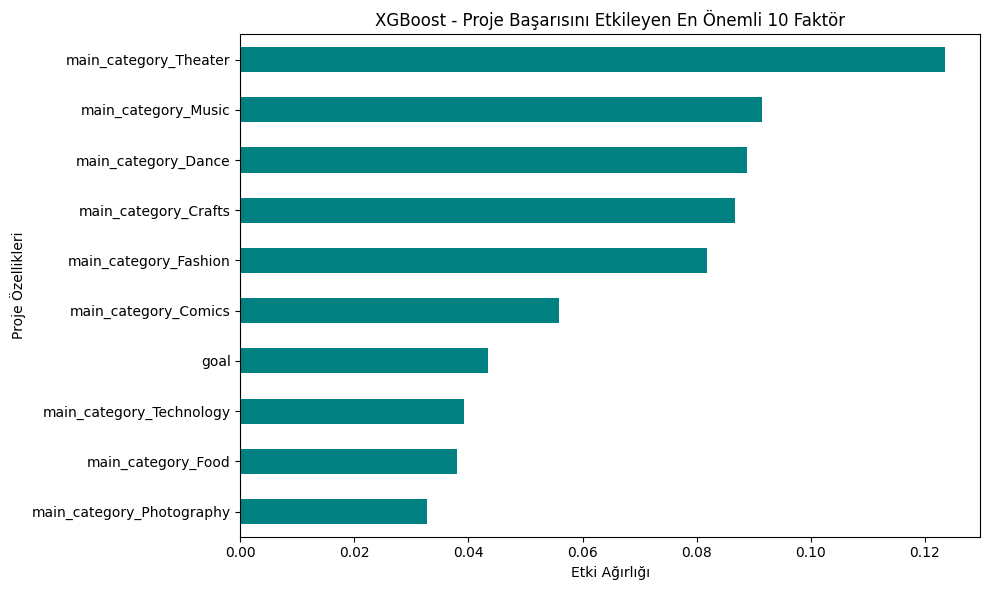

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# ==========================================
# 1. VERİYİ YÜKLEME VE TEMİZLEME
# ==========================================
print("Veri yükleniyor ve ön işleme yapılıyor...")

# HATA ÖNLEYİCİ: Özel karakterleri (latin1) ve bozuk satırları (on_bad_lines) atla
df = pd.read_csv('kickstarter.csv', encoding='latin1', on_bad_lines='skip')

# HATA ÖNLEYİCİ: Sütun isimlerindeki gizli boşlukları tıraşla
df.columns = df.columns.str.strip()

# ==========================================
# 2. HEDEF DEĞİŞKEN (TARGET) AYARLAMASI
# ==========================================
# Sadece sonucu belli olan projeleri alındı
df = df[df['state'].isin(['successful', 'failed'])].copy()

# Makinenin anlaması için Başarılı=1, Başarısız=0 yapıyoruz
df['state'] = df['state'].map({'successful': 1, 'failed': 0})

# ==========================================
# 3. ÖZELLİK MÜHENDİSLİĞİ (FEATURE ENGINEERING)
# ==========================================
# HATA DÜZELTME: 'goal' sütununu zorla sayısal (float) formata çevrildi.
# Sayıya çevrilemeyen kirli satırlar NaN olarak işaretlendi.
df['goal'] = pd.to_numeric(df['goal'], errors='coerce')

# Tarihleri matematiksel işleme sokup 'Kampanya Süresi' gün olarak bulundu
df['deadline'] = pd.to_datetime(df['deadline'])
df['launched'] = pd.to_datetime(df['launched'])
df['duration_days'] = (df['deadline'] - df['launched']).dt.days

# VERİ SIZINTISINI (DATA LEAKAGE) ÖNLEME:
# Sadece modelin başlangıçta bilebileceği sütunları seçilmeli.
features_to_keep = ['main_category', 'country', 'goal', 'duration_days', 'state']
df = df[features_to_keep]

# Eksik (ve to_numeric ile NaN'a dönüşen kirli) satırları siliyoruz
df = df.dropna()

# Kategorik veriler (Ülke, Kategori) One-Hot Encoding ile sütunlara ayırıldı.
df = pd.get_dummies(df, columns=['main_category', 'country'], drop_first=True)
# ==========================================
# 4. MAKİNE ÖĞRENMESİ HAZIRLIĞI
# ==========================================
X = df.drop('state', axis=1)
y = df['state']

# Verinin %80'i Eğitim (Train), %20'si Test için ayrıldı
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Sadece Logistic Regression için sayısal verileri standartlaştırıyoruz
scaler = StandardScaler()
cols_to_scale = ['goal', 'duration_days']
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# ==========================================
# 5. MODELLERİN EĞİTİLMESİ
# ==========================================
print("Modeller eğitiliyor, bu işlem yaklaşık 1-2 dakika sürebilir...\n")

# Model 1: Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
log_preds = log_model.predict(X_test_scaled)
log_acc = accuracy_score(y_test, log_preds)

# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

# Model 3: XGBoost
# HATA ÖNLEYİCİ: XGBoost sütun isimlerindeki boşluk vb. özel karakterleri temizlendi.
X_train.columns = X_train.columns.str.replace('[ \[\]<>]', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[ \[\]<>]', '_', regex=True)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)

# ==========================================
# 6. SONUÇLAR VE GÖRSELLEŞTİRME
# ==========================================
print("-" * 40)
print("MODEL DOĞRULUK (ACCURACY) SONUÇLARI")
print("-" * 40)
print(f"Logistic Regression: %{log_acc*100:.2f}")
print(f"Random Forest      : %{rf_acc*100:.2f}")
print(f"XGBoost            : %{xgb_acc*100:.2f}\n")

# Görsel 1: Karmaşıklık Matrisleri
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
predictions = [log_preds, rf_preds, xgb_preds]

for i, ax in enumerate(axes):
    cm = confusion_matrix(y_test, predictions[i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{models[i]} Confusion Matrix')
    ax.set_xlabel('Modelin Tahmini')
    ax.set_ylabel('Gerçek Durum')
    ax.xaxis.set_ticklabels(['Başarısız (0)', 'Başarılı (1)'])
    ax.yaxis.set_ticklabels(['Başarısız (0)', 'Başarılı (1)'])
plt.tight_layout()
plt.show()

# Görsel 2: XGBoost Özellik Önemi Grafiği
feature_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
top_features = feature_importances.nlargest(10)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh', color='teal')
plt.title('XGBoost - Proje Başarısını Etkileyen En Önemli 10 Faktör')
plt.xlabel('Etki Ağırlığı')
plt.ylabel('Proje Özellikleri')
plt.tight_layout()
plt.show()

--------------------------------------------------
XGBOOST DETAYLI SINIFLANDIRMA RAPORU (F1-SCORE, PRECISION, RECALL)
--------------------------------------------------
               precision    recall  f1-score   support

Başarısız (0)       0.69      0.80      0.74     33553
 Başarılı (1)       0.61      0.47      0.53     22708

     accuracy                           0.67     56261
    macro avg       0.65      0.64      0.64     56261
 weighted avg       0.66      0.67      0.66     56261



/tmp/ipykernel_4826/3105570839.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='state', data=df, ax=axes[0], palette=['#e74c3c', '#2ecc71'])


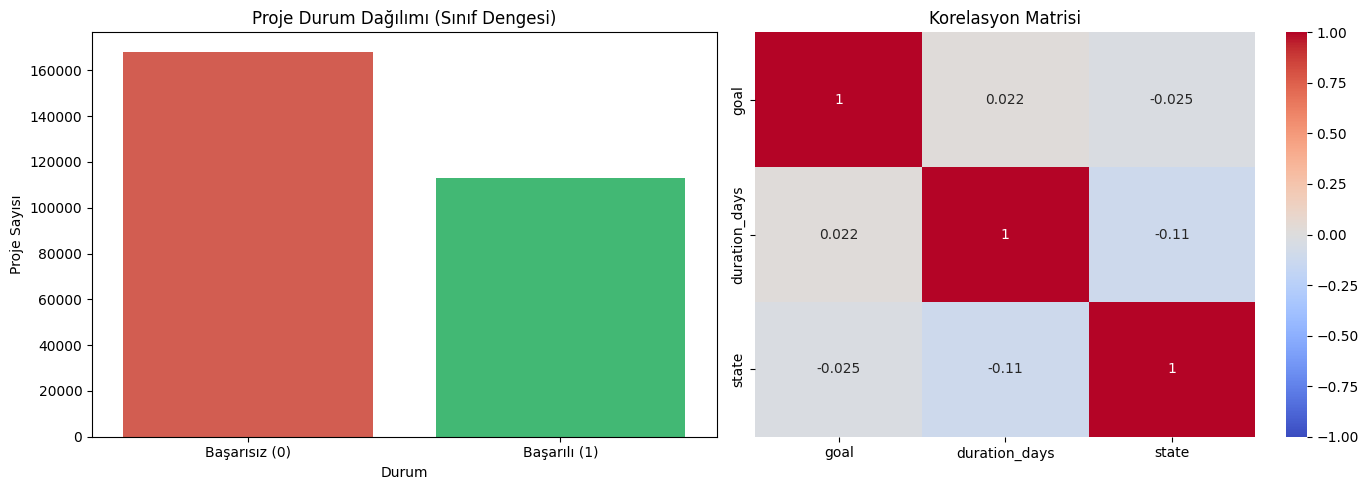

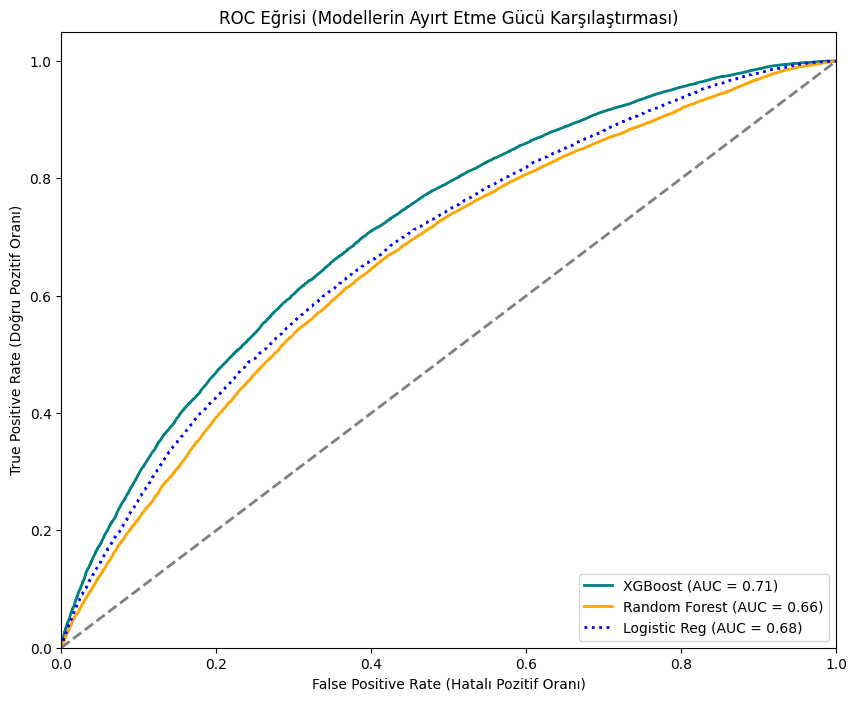

In [ ]:
from sklearn.metrics import roc_curve, auc, classification_report
import warnings

# HATA ÖNLEYİCİ: İsimlendirme by-pass'ı yaparken çıkacak kırmızı uyarı mesajlarını gizle
warnings.filterwarnings("ignore", category=UserWarning)

# ==========================================
# 7. AKADEMİK GÖRSELLEŞTİRMELER (EDA & ROC)
# ==========================================

print("-" * 50)
print("XGBOOST DETAYLI SINIFLANDIRMA RAPORU (F1-SCORE, PRECISION, RECALL)")
print("-" * 50)
print(classification_report(y_test, xgb_preds, target_names=['Başarısız (0)', 'Başarılı (1)']))


# --- Görsel 3: Keşifsel Veri Analizi (EDA) Grafikleri ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='state', data=df, ax=axes[0], palette=['#e74c3c', '#2ecc71'])
axes[0].set_title('Proje Durum Dağılımı (Sınıf Dengesi)')
axes[0].set_xticklabels(['Başarısız (0)', 'Başarılı (1)'])
axes[0].set_xlabel('Durum')
axes[0].set_ylabel('Proje Sayısı')

numeric_df = df[['goal', 'duration_days', 'state']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Korelasyon Matrisi')

plt.tight_layout()
plt.show()


# --- Görsel 4: ROC Eğrisi ve AUC (Modellerin Karşılaştırması) ---
plt.figure(figsize=(10, 8))

# HATA DÜZELTİLDİ: ".values" eklenerek sütun ismi kontrolü by-pass edildi
log_prob = log_model.predict_proba(X_test_scaled.values)[:, 1]
rf_prob = rf_model.predict_proba(X_test.values)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# ROC Eğrisi değerlerini hesaplıyoruz
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)

# Çizim işlemleri
plt.plot(fpr_xgb, tpr_xgb, color='teal', lw=2, label=f'XGBoost (AUC = {auc(fpr_xgb, tpr_xgb):.2f})')
plt.plot(fpr_rf, tpr_rf, color='orange', lw=2, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.2f})')
plt.plot(fpr_log, tpr_log, color='blue', lw=2, linestyle=':', label=f'Logistic Reg (AUC = {auc(fpr_log, tpr_log):.2f})')

# Rastgele tahmin çizgisi (Kader/Şans çizgisi)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Hatalı Pozitif Oranı)')
plt.ylabel('True Positive Rate (Doğru Pozitif Oranı)')
plt.title('ROC Eğrisi (Modellerin Ayırt Etme Gücü Karşılaştırması)')
plt.legend(loc="lower right")
plt.show()